In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver


from langchain_huggingface import HuggingFaceEndpoint
from langchain_huggingface.chat_models import ChatHuggingFace
from dotenv import load_dotenv
import os

In [23]:
load_dotenv()

# Initialize HuggingFace LLM
llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_KEY")
)

model = ChatHuggingFace(llm=llm)

In [24]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [25]:
def chat_node(state: ChatState):

    # Take user query from state
    messages = state['messages']

    # Generate response using the model
    response = model.invoke(messages)

    # Append the response to the state messages
    return {'messages': [response]}

In [26]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)


# Add nodes to the graph
graph.add_node('chat_node', chat_node)


graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

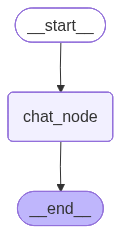

In [27]:
chatbot

In [28]:
initial_state = {
    'messages': [HumanMessage(content="can you assist me like a personal agent?")]
}
thread_id = "user_chat_thread_1"
config = {'configurable': {'thread_id': thread_id}}
chatbot.invoke(initial_state, config=config)['messages'][-1].content

'Absolutely! I’m happy to act as your personal assistant. Whether you need help organizing your schedule, brainstorming ideas, drafting emails, researching information, setting reminders, planning a trip, or anything else—just let me know what you’d like to tackle, and we’ll get started.  \n\n**How would you like to begin?**  \n- 📅 Managing appointments or to‑do lists  \n- ✈️ Planning travel or events  \n- 📝 Drafting or editing documents and messages  \n- 🔍 Researching topics or finding resources  \n- 💡 Brainstorming ideas or problem‑solving  \n\nFeel free to share any details or priorities, and I’ll tailor my support to fit your needs.'

In [29]:
thread_id = "user_chat_thread_1"

while True:
    user_input  = input ("You: ")

    print ("\nUser:", user_input)

    if user_input.strip().lower() in ['exit', 'quit']:
        print("Exiting the chat. Goodbye!")
        break

    else:
        initial_state = {
            'messages': [HumanMessage(content=user_input)]
        }

        config = {'configurable': {'thread_id': thread_id}}

        response = chatbot.invoke(initial_state, config=config)
        print("\nBot:", response['messages'][-1].content)


User: hello my name is aminul

Bot: Hi Aminul! 👋 Nice to meet you. How can I assist you today? Whether it’s planning something, organizing tasks, drafting a message, or just answering a question, I’m here to help. Let me know what you need!

User: can you tell my name?

Bot: Your name is Aminul. Let me know what I can do for you, Aminul!

User: what 10 + 20?

Bot: 10 + 20 = 30.

User: subtract 10 from the result

Bot: 30 − 10 = 20.

User: multiply the result with 2

Bot: 20 × 2 = 40.

User: hmmm

Bot: Got it! 😊 If you’d like to keep playing with the numbers, try another operation, or if there’s something else you need help with, just let me know!

User: .

Bot: It looks like you might have sent a placeholder. How can I help you next? Feel free to let me know what you’d like to do—whether it’s more math, a question, or anything else!

User: exit
Exiting the chat. Goodbye!


In [31]:
chatbot.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='can you assist me like a personal agent?', additional_kwargs={}, response_metadata={}, id='d6016f04-fada-4180-94bc-7f07647123e5'), AIMessage(content='Absolutely! I’m happy to act as your personal assistant. Whether you need help organizing your schedule, brainstorming ideas, drafting emails, researching information, setting reminders, planning a trip, or anything else—just let me know what you’d like to tackle, and we’ll get started.  \n\n**How would you like to begin?**  \n- 📅 Managing appointments or to‑do lists  \n- ✈️ Planning travel or events  \n- 📝 Drafting or editing documents and messages  \n- 🔍 Researching topics or finding resources  \n- 💡 Brainstorming ideas or problem‑solving  \n\nFeel free to share any details or priorities, and I’ll tailor my support to fit your needs.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 230, 'prompt_tokens': 80, 'total_tokens': 310}, 'model_name': 'openai